<a href="https://colab.research.google.com/github/cduplan59/CFT_analysis/blob/main/ROSG_energy_rigidity_iteration_calibration_corrected.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ROSG — Energy-rigidity probe with iteration-dependent calibration

## Corrected formulation including the user constraint

This notebook corrects the previous dimensionless version by adding the missing point:

\[
\left(\frac{G}{c^4}\right)_{i=1}
\]

is treated as the **post-metric calibration value at the first effective iteration**. It is not an internal pre-metric unit. If the iterative depth tends toward the fully pre-metric limit, the response associated with \(G/c^4\) is allowed to diverge:

\[
\widehat\Gamma(i)\equiv
\frac{\chi_i}{\chi_{i=1}},
\qquad
\widehat\Gamma(1)=1,
\qquad
\lim_{i\to\infty}\widehat\Gamma(i)=+\infty.
\]

The internal chain therefore becomes:

\[
m_{RG}(Z)
\rightarrow R_K(Z)
\rightarrow \widehat\Gamma(i)
\rightarrow
\widehat\chi(i,Z)=\frac{\widehat\Gamma(i)}{R_K(Z)},
\qquad
\widehat K(i,Z)=\frac{R_K(Z)}{\widehat\Gamma(i)}.
\]

Thus, a finite UV-rigidity factor \(R_K(Z)\) cannot by itself prevent the divergence of the compliance when \(i\to\infty\). To preserve a true rigidity in that limit, \(R_K\) would need to diverge at least as fast as \(\widehat\Gamma(i)\).

No \(\mathrm{m/J}\) or \(\mathrm{J/m}\) interpretation is made inside the pre-metric sector.

## Physical reading

- \(i=1\): first calibrated metric reading; the previous dimensionless model is recovered.
- \(i>1\): iterative pre-metric departure; the compliance factor \(\widehat\Gamma(i)\) grows.
- \(i\to\infty\): if \(\widehat\Gamma(i)\to\infty\), then \(\widehat\chi\to\infty\) and \(\widehat K\to0\) unless \(R_K\) also diverges.

This means that the phrase “rigidity énergétique” must be used carefully. A divergent \(G/c^4\)-type response corresponds to **hyper-compliance**, not intrinsic rigidification, unless a stronger counter-response is introduced.

In [1]:
# ============================================================
# 1. Imports, Colab Drive, directories
# ============================================================
import os, json, math, zipfile, platform, warnings
from pathlib import Path
from dataclasses import dataclass, asdict, replace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=RuntimeWarning)
np.set_printoptions(precision=6, suppress=True)

try:
    from google.colab import drive, files
    IN_COLAB = True
except Exception:
    IN_COLAB = False

USE_GOOGLE_DRIVE = True
DRIVE_ROOT = "/content/drive/MyDrive/ROSG_energy_rigidity_iteration_calibration"
LOCAL_OUT_DIR = Path("/content/ROSG_energy_rigidity_iteration_calibration_outputs")

if IN_COLAB and USE_GOOGLE_DRIVE:
    if not os.path.exists("/content/drive/MyDrive"):
        drive.mount("/content/drive", force_remount=False)
    OUT_DIR = Path(DRIVE_ROOT)
else:
    OUT_DIR = LOCAL_OUT_DIR

FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Python:", platform.python_version())
print("Running in Colab:", IN_COLAB)
print("OUT_DIR:", OUT_DIR)

Mounted at /content/drive
Python: 3.12.13
Running in Colab: True
OUT_DIR: /content/drive/MyDrive/ROSG_energy_rigidity_iteration_calibration


In [2]:
# ============================================================
# 2. Optional external post-geometrization calibration constants
# ============================================================
# These constants are NOT internal pre-metric units.
# They are written only as metadata for the i=1 post-metric calibration.

ENABLE_POSTMETRIC_SI_METADATA = True

if ENABLE_POSTMETRIC_SI_METADATA:
    c_SI = 299_792_458.0
    G_SI = 6.67430e-11
    hbar_SI = 1.054_571_817e-34
    chi_i1_external_m_per_J = G_SI / c_SI**4
    K_i1_external_J_per_m = c_SI**4 / G_SI
else:
    c_SI = G_SI = hbar_SI = np.nan
    chi_i1_external_m_per_J = K_i1_external_J_per_m = np.nan

external_calibration = {
    "status": "metadata_only_for_i_equals_1_postmetric_calibration",
    "warning": "Do not use m/J or J/m inside the pre-metric iteration.",
    "chi_i1_external_m_per_J": chi_i1_external_m_per_J,
    "K_i1_external_J_per_m": K_i1_external_J_per_m,
}

with open(OUT_DIR / "external_i1_calibration_metadata.json", "w") as f:
    json.dump(external_calibration, f, indent=2)

print(json.dumps(external_calibration, indent=2))

{
  "status": "metadata_only_for_i_equals_1_postmetric_calibration",
  "warning": "Do not use m/J or J/m inside the pre-metric iteration.",
  "chi_i1_external_m_per_J": 8.262717639698037e-45,
  "K_i1_external_J_per_m": 1.2102555643382063e+44
}


In [3]:
# ============================================================
# 3. Configuration
# ============================================================
@dataclass
class IterationRigidityConfig:
    # Z-grid.
    z_min: float = -2.0
    z_max: float = 6.0
    n_z: int = 241

    # Track 2bis-like RG conductance sigmoid, N50 main-run values.
    Z_th_RG: float = 1.344
    Delta_Z_RG: float = 0.516

    # Spectral target values from Test 1 / Test1K, used only for comparison.
    d_uv: float = 2.066
    d_ir: float = 2.688
    Z_th_spec: float = 1.731
    Delta_Z_spec: float = 1.050

    # Dimensionless response amplitude.
    # With UV_RIGID_IR_GR, eta_K > 0 gives finite UV rigidification at fixed i.
    eta_K: float = 0.50
    response_mode: str = "UV_RIGID_IR_GR"

    # Iteration-dependent compliance amplification.
    # Gamma_i = 1 at i=1 and diverges when i -> infinity.
    iteration_model: str = "exponential"  # exponential, power, pole_regularized
    i_value: float = 1.0
    lambda_i: float = 0.08       # exponential growth rate
    power_i: float = 1.0         # power growth exponent
    i_pole: float = 100.0        # finite-pole diagnostic, not the default
    pole_epsilon: float = 1e-9

    # Safety clipping for log response R_K only, not for Gamma_i.
    max_abs_log_RK: float = 5.0

cfg = IterationRigidityConfig()
Z = np.linspace(cfg.z_min, cfg.z_max, cfg.n_z)

with open(OUT_DIR / "iteration_rigidity_config.json", "w") as f:
    json.dump(asdict(cfg), f, indent=2)

print(json.dumps(asdict(cfg), indent=2))

{
  "z_min": -2.0,
  "z_max": 6.0,
  "n_z": 241,
  "Z_th_RG": 1.344,
  "Delta_Z_RG": 0.516,
  "d_uv": 2.066,
  "d_ir": 2.688,
  "Z_th_spec": 1.731,
  "Delta_Z_spec": 1.05,
  "eta_K": 0.5,
  "response_mode": "UV_RIGID_IR_GR",
  "iteration_model": "exponential",
  "i_value": 1.0,
  "lambda_i": 0.08,
  "power_i": 1.0,
  "i_pole": 100.0,
  "pole_epsilon": 1e-09,
  "max_abs_log_RK": 5.0
}


In [4]:
# ============================================================
# 4. Order parameters and finite Z-response R_K(Z)
# ============================================================
def sigmoid_tanh(Z, Z_th, Delta_Z):
    Z = np.asarray(Z, dtype=float)
    return 0.5 * (1.0 + np.tanh((Z - Z_th) / max(Delta_Z, 1e-12)))

def m_RG(Z, cfg):
    return sigmoid_tanh(Z, cfg.Z_th_RG, cfg.Delta_Z_RG)

def ds_eff_spectral_template(Z, cfg):
    M = sigmoid_tanh(Z, cfg.Z_th_spec, cfg.Delta_Z_spec)
    return cfg.d_uv + (cfg.d_ir - cfg.d_uv) * M

def normalized_from_ds(ds, cfg):
    return np.clip((np.asarray(ds) - cfg.d_uv) / (cfg.d_ir - cfg.d_uv), 0.0, 1.0)

def rigidity_response_RK(Z, cfg):
    Z = np.asarray(Z, dtype=float)
    M_rg = m_RG(Z, cfg)
    ds = ds_eff_spectral_template(Z, cfg)
    M_ds = normalized_from_ds(ds, cfg)

    if cfg.response_mode == "UV_RIGID_IR_GR":
        logR = cfg.eta_K * (1.0 - M_rg)
    elif cfg.response_mode == "UV_COMPLIANT_IR_GR":
        logR = cfg.eta_K * (M_rg - 1.0)
    elif cfg.response_mode == "UV_GR_IR_RIGID":
        logR = cfg.eta_K * M_rg
    elif cfg.response_mode == "SPECTRAL_UV_RIGID_IR_GR":
        logR = cfg.eta_K * (1.0 - M_ds)
    else:
        raise ValueError(f"Unknown response_mode: {cfg.response_mode}")

    logR = np.clip(logR, -cfg.max_abs_log_RK, cfg.max_abs_log_RK)
    return np.exp(logR), logR

M_rg = m_RG(Z, cfg)
ds_template = ds_eff_spectral_template(Z, cfg)
M_ds = normalized_from_ds(ds_template, cfg)
R_K, log_R_K = rigidity_response_RK(Z, cfg)

profiles_base = pd.DataFrame({
    "Z": Z,
    "m_RG": M_rg,
    "ds_template": ds_template,
    "normalized_ds_order": M_ds,
    "log_R_K_finite_Z_response": log_R_K,
    "R_K_finite_Z_response": R_K,
})

profiles_base.to_csv(OUT_DIR / "finite_Z_response_profiles.csv", index=False)
profiles_base.head()

,Z,m_RG,ds_template,normalized_ds_order,log_R_K_finite_Z_response,R_K_finite_Z_response
0,-2.000000,0.000002,2.066509,0.000819,0.499999,1.648719
1,-1.966667,0.000003,2.066543,0.000873,0.499999,1.648719
2,-1.933333,0.000003,2.066578,0.000930,0.499998,1.648719
3,-1.900000,0.000003,2.066616,0.000991,0.499998,1.648718
4,-1.866667,0.000004,2.066657,0.001055,0.499998,1.648718


In [5]:
# ============================================================
# 5. Iteration-dependent calibration Gamma(i)
# ============================================================
def Gamma_iteration(i, cfg):
    """Dimensionless compliance amplification relative to the i=1 calibration.

    Gamma(1)=1 and Gamma(i)->infinity for the exponential and power models.
    The pole_regularized model is a diagnostic with a finite pole at i_pole.
    """
    i = np.asarray(i, dtype=float)
    i_eff = np.maximum(i, 1.0)

    if cfg.iteration_model == "exponential":
        return np.exp(cfg.lambda_i * (i_eff - 1.0))
    elif cfg.iteration_model == "power":
        return np.power(i_eff, cfg.power_i)
    elif cfg.iteration_model == "pole_regularized":
        denom = np.maximum(cfg.i_pole - i_eff, cfg.pole_epsilon)
        return (cfg.i_pole - 1.0) / denom
    else:
        raise ValueError(f"Unknown iteration_model: {cfg.iteration_model}")

Gamma_i = float(Gamma_iteration(cfg.i_value, cfg))

# Corrected internal dimensionless quantities.
# At i=1: Gamma_i=1 and the previous dimensionless notebook is recovered.
# As i->infinity: Gamma_i->infinity, so finite R_K cannot stop chi_hat divergence.
K_hat_iZ = R_K / Gamma_i
chi_hat_iZ = Gamma_i / R_K
compactness_ratio_hat_iZ = chi_hat_iZ

profiles = profiles_base.copy()
profiles["i_value"] = cfg.i_value
profiles["Gamma_i_compliance_amplification"] = Gamma_i
profiles["K_hat_iZ_relative"] = K_hat_iZ
profiles["chi_hat_iZ_relative"] = chi_hat_iZ
profiles["compactness_ratio_hat_iZ"] = compactness_ratio_hat_iZ

# For comparison with the previous i=1-only reading.
profiles["K_hat_if_i_equals_1"] = R_K
profiles["chi_hat_if_i_equals_1"] = 1.0 / R_K

profiles.to_csv(OUT_DIR / "iteration_energy_rigidity_profiles.csv", index=False)
profiles.head()

,Z,m_RG,ds_template,normalized_ds_order,log_R_K_finite_Z_response,R_K_finite_Z_response,i_value,Gamma_i_compliance_amplification,K_hat_iZ_relative,chi_hat_iZ_relative,compactness_ratio_hat_iZ,K_hat_if_i_equals_1,chi_hat_if_i_equals_1
0,-2.000000,0.000002,2.066509,0.000819,0.499999,1.648719,1.0,1.0,1.648719,0.606531,0.606531,1.648719,0.606531
1,-1.966667,0.000003,2.066543,0.000873,0.499999,1.648719,1.0,1.0,1.648719,0.606531,0.606531,1.648719,0.606531
2,-1.933333,0.000003,2.066578,0.000930,0.499998,1.648719,1.0,1.0,1.648719,0.606532,0.606532,1.648719,0.606532
3,-1.900000,0.000003,2.066616,0.000991,0.499998,1.648718,1.0,1.0,1.648718,0.606532,0.606532,1.648718,0.606532
4,-1.866667,0.000004,2.066657,0.001055,0.499998,1.648718,1.0,1.0,1.648718,0.606532,0.606532,1.648718,0.606532


## Key consequence

With the corrected iteration factor:

\[
\widehat K(i,Z)=\frac{R_K(Z)}{\widehat\Gamma(i)},
\qquad
\widehat\chi(i,Z)=\frac{\widehat\Gamma(i)}{R_K(Z)}.
\]

Therefore, if \(R_K(Z)\) is bounded and \(\widehat\Gamma(i)\to\infty\):

\[
\lim_{i\to\infty}\widehat K(i,Z)=0,
\qquad
\lim_{i\to\infty}\widehat\chi(i,Z)=+\infty.
\]

This is not a defect of the code; it is the mathematical consequence of treating \(G/c^4\) as an \(i=1\) calibration whose effective value diverges toward the pre-metric limit.

In [6]:
# ============================================================
# 6. Key checkpoints
# ============================================================
def interp_at(x, y, x0):
    return float(np.interp(x0, x, y))

key_points = [
    ("UV_edge", float(Z[0])),
    ("Z_th_RG", cfg.Z_th_RG),
    ("Z_th_spec", cfg.Z_th_spec),
    ("IR_edge", float(Z[-1])),
]

rows = []
for name, z0 in key_points:
    rows.append({
        "point": name,
        "Z": z0,
        "i_value": cfg.i_value,
        "Gamma_i": Gamma_i,
        "m_RG": interp_at(Z, M_rg, z0),
        "R_K_finite_Z_response": interp_at(Z, R_K, z0),
        "K_hat_iZ_relative": interp_at(Z, K_hat_iZ, z0),
        "chi_hat_iZ_relative": interp_at(Z, chi_hat_iZ, z0),
        "K_hat_if_i_equals_1": interp_at(Z, R_K, z0),
        "chi_hat_if_i_equals_1": interp_at(Z, 1.0/R_K, z0),
    })

checkpoint_df = pd.DataFrame(rows)
checkpoint_df.to_csv(OUT_DIR / "iteration_key_points.csv", index=False)
checkpoint_df

,point,Z,i_value,Gamma_i,m_RG,R_K_finite_Z_response,K_hat_iZ_relative,chi_hat_iZ_relative,K_hat_if_i_equals_1,chi_hat_if_i_equals_1
0,UV_edge,-2.000,1.0,1.0,0.000002,1.648719,1.648719,0.606531,1.648719,0.606531
1,Z_th_RG,1.344,1.0,1.0,0.499996,1.284064,1.284064,0.778822,1.284064,0.778822
2,Z_th_spec,1.731,1.0,1.0,0.817523,1.095534,1.095534,0.912803,1.095534,0.912803
3,IR_edge,6.000,1.0,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
# ============================================================
# 7. Iteration scan: where does the divergence dominate?
# ============================================================
i_grid = np.concatenate([
    np.arange(1, 21, 1, dtype=float),
    np.arange(25, 101, 5, dtype=float),
    np.arange(120, 501, 20, dtype=float),
])

scan_rows = []
for i in i_grid:
    Gami = float(Gamma_iteration(i, cfg))
    for point_name, z0 in key_points:
        RK0 = interp_at(Z, R_K, z0)
        scan_rows.append({
            "i": i,
            "Gamma_i": Gami,
            "point": point_name,
            "Z": z0,
            "R_K_Z": RK0,
            "K_hat_iZ": RK0 / Gami,
            "chi_hat_iZ": Gami / RK0,
        })

iteration_scan = pd.DataFrame(scan_rows)
iteration_scan.to_csv(OUT_DIR / "iteration_divergence_scan.csv", index=False)
iteration_scan.head()

,i,Gamma_i,point,Z,R_K_Z,K_hat_iZ,chi_hat_iZ
0,1.0,1.000000,UV_edge,-2.000,1.648719,1.648719,0.606531
1,1.0,1.000000,Z_th_RG,1.344,1.284064,1.284064,0.778777
2,1.0,1.000000,Z_th_spec,1.731,1.095534,1.095534,0.912797
3,1.0,1.000000,IR_edge,6.000,1.000000,1.000000,1.000000
4,2.0,1.083287,UV_edge,-2.000,1.648719,1.521960,0.657048


In [8]:
# ============================================================
# 8. Eta_K vs iteration growth-rate scan
# ============================================================
eta_grid = np.linspace(0.0, 3.0, 121)
lambda_grid = np.linspace(0.0, 0.20, 81)
i_eval = 100.0

phase_rows = []
for eta in eta_grid:
    c_eta = replace(cfg, eta_K=float(eta), i_value=1.0)
    RK_eta, _ = rigidity_response_RK(np.array([cfg.z_min]), c_eta)
    RK_UV = float(RK_eta[0])
    for lam in lambda_grid:
        c_lam = replace(cfg, lambda_i=float(lam), iteration_model="exponential")
        Gam = float(Gamma_iteration(i_eval, c_lam))
        phase_rows.append({
            "eta_K": float(eta),
            "lambda_i": float(lam),
            "i_eval": i_eval,
            "R_K_UV": RK_UV,
            "Gamma_i": Gam,
            "K_hat_UV_at_i": RK_UV / Gam,
            "chi_hat_UV_at_i": Gam / RK_UV,
            "finite_rigidity_survives_at_i": bool(RK_UV / Gam >= 1.0),
        })

phase_scan = pd.DataFrame(phase_rows)
phase_scan.to_csv(OUT_DIR / "etaK_vs_iteration_growth_phase_scan.csv", index=False)
phase_scan.head()

,eta_K,lambda_i,i_eval,R_K_UV,Gamma_i,K_hat_UV_at_i,chi_hat_UV_at_i,finite_rigidity_survives_at_i
0,0.0,0.0000,100.0,1.0,1.000000,1.000000,1.000000,True
1,0.0,0.0025,100.0,1.0,1.280819,0.780750,1.280819,False
2,0.0,0.0050,100.0,1.0,1.640498,0.609571,1.640498,False
3,0.0,0.0075,100.0,1.0,2.101182,0.475923,2.101182,False
4,0.0,0.0100,100.0,1.0,2.691234,0.371577,2.691234,False


In [9]:
# ============================================================
# 9. Sanity checks
# ============================================================
cfg_i1 = replace(cfg, i_value=1.0)
Gamma_i1 = float(Gamma_iteration(1.0, cfg_i1))
RK_i1, _ = rigidity_response_RK(Z, cfg_i1)

# A deliberately large i to verify direction of the divergence.
i_large = 1e6
Gamma_large = float(Gamma_iteration(i_large, cfg))

checks = {
    "internal_units_are_dimensionless": True,
    "G_over_c4_is_i1_external_calibration_only": True,
    "Gamma_i_equals_1_at_i1": bool(np.isclose(Gamma_i1, 1.0)),
    "Gamma_i_increases_for_large_i": bool(Gamma_large > Gamma_i1),
    "Gamma_i_large_is_finite_numerically_for_test": bool(np.isfinite(Gamma_large)),
    "positive_R_K": bool(np.all(R_K > 0)),
    "positive_K_hat_iZ": bool(np.all(K_hat_iZ > 0)),
    "positive_chi_hat_iZ": bool(np.all(chi_hat_iZ > 0)),
    "i1_recovers_previous_dimensionless_reading": bool(np.allclose(RK_i1 / Gamma_i1, RK_i1)),
    "bounded_R_K_cannot_cancel_infinite_Gamma": "analytical consequence: if R_K bounded and Gamma_i->infinity, K_hat->0 and chi_hat->infinity",
}

with open(OUT_DIR / "iteration_sanity_checks.json", "w") as f:
    json.dump(checks, f, indent=2)

print(json.dumps(checks, indent=2))

{
  "internal_units_are_dimensionless": true,
  "G_over_c4_is_i1_external_calibration_only": true,
  "Gamma_i_equals_1_at_i1": true,
  "Gamma_i_increases_for_large_i": true,
  "Gamma_i_large_is_finite_numerically_for_test": false,
  "positive_R_K": true,
  "positive_K_hat_iZ": true,
  "positive_chi_hat_iZ": true,
  "i1_recovers_previous_dimensionless_reading": true,
  "bounded_R_K_cannot_cancel_infinite_Gamma": "analytical consequence: if R_K bounded and Gamma_i->infinity, K_hat->0 and chi_hat->infinity"
}


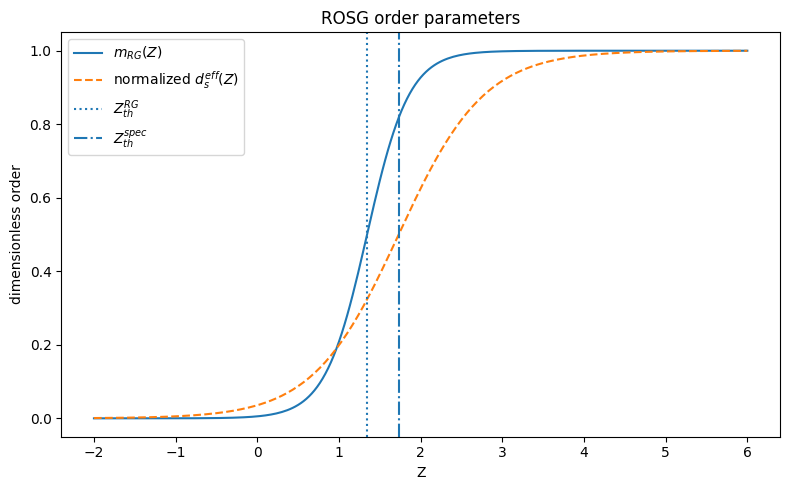

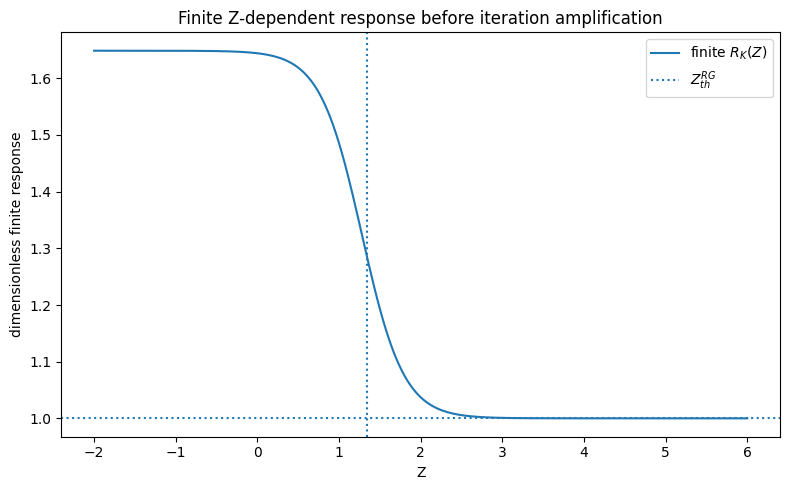

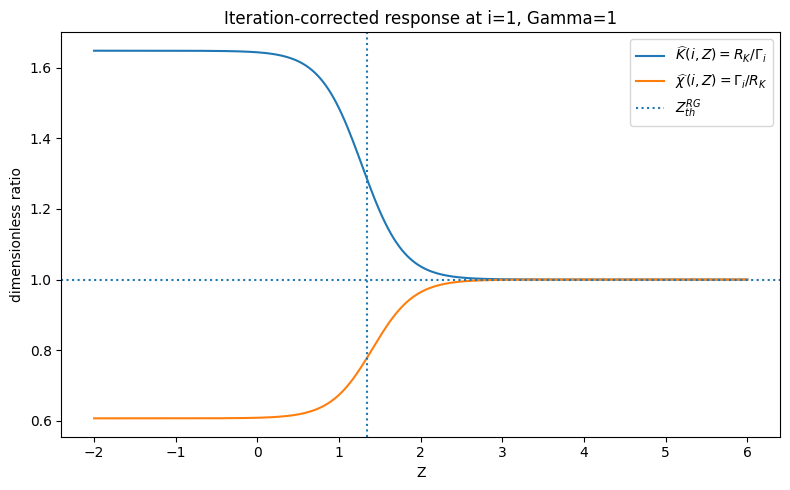

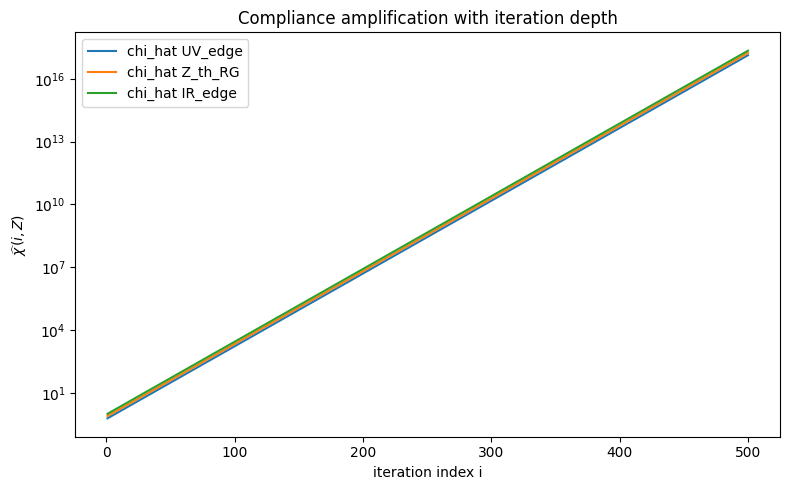

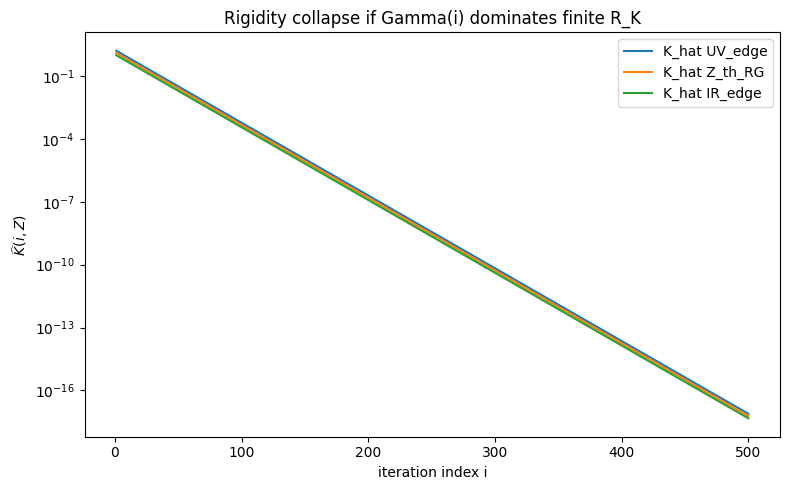

In [10]:
# ============================================================
# 10. Plots
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(profiles["Z"], profiles["m_RG"], label=r"$m_{RG}(Z)$")
plt.plot(profiles["Z"], profiles["normalized_ds_order"], label=r"normalized $d_s^{eff}(Z)$", linestyle="--")
plt.axvline(cfg.Z_th_RG, linestyle=":", label=r"$Z_{th}^{RG}$")
plt.axvline(cfg.Z_th_spec, linestyle="-.", label=r"$Z_{th}^{spec}$")
plt.xlabel("Z")
plt.ylabel("dimensionless order")
plt.title("ROSG order parameters")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "01_order_parameters.png", dpi=160)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(profiles["Z"], profiles["R_K_finite_Z_response"], label=r"finite $R_K(Z)$")
plt.axhline(1.0, linestyle=":")
plt.axvline(cfg.Z_th_RG, linestyle=":", label=r"$Z_{th}^{RG}$")
plt.xlabel("Z")
plt.ylabel("dimensionless finite response")
plt.title("Finite Z-dependent response before iteration amplification")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "02_finite_RK_response.png", dpi=160)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(profiles["Z"], profiles["K_hat_iZ_relative"], label=r"$\widehat K(i,Z)=R_K/\Gamma_i$")
plt.plot(profiles["Z"], profiles["chi_hat_iZ_relative"], label=r"$\widehat\chi(i,Z)=\Gamma_i/R_K$")
plt.axhline(1.0, linestyle=":")
plt.axvline(cfg.Z_th_RG, linestyle=":", label=r"$Z_{th}^{RG}$")
plt.xlabel("Z")
plt.ylabel("dimensionless ratio")
plt.title(f"Iteration-corrected response at i={cfg.i_value:g}, Gamma={Gamma_i:.3g}")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "03_iteration_corrected_K_chi.png", dpi=160)
plt.show()

plt.figure(figsize=(8, 5))
for point_name in ["UV_edge", "Z_th_RG", "IR_edge"]:
    sub = iteration_scan[iteration_scan["point"] == point_name]
    plt.semilogy(sub["i"], sub["chi_hat_iZ"], label=f"chi_hat {point_name}")
plt.xlabel("iteration index i")
plt.ylabel(r"$\widehat\chi(i,Z)$")
plt.title("Compliance amplification with iteration depth")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "04_iteration_compliance_divergence.png", dpi=160)
plt.show()

plt.figure(figsize=(8, 5))
for point_name in ["UV_edge", "Z_th_RG", "IR_edge"]:
    sub = iteration_scan[iteration_scan["point"] == point_name]
    plt.semilogy(sub["i"], sub["K_hat_iZ"], label=f"K_hat {point_name}")
plt.xlabel("iteration index i")
plt.ylabel(r"$\widehat K(i,Z)$")
plt.title("Rigidity collapse if Gamma(i) dominates finite R_K")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "05_iteration_rigidity_collapse.png", dpi=160)
plt.show()

## Reviewer-safe interpretation

The corrected reading is:

1. \(G/c^4\) is not an internal pre-metric quantity in \(\mathrm{m/J}\).
2. \(G/c^4\) is used only as a post-metric calibration at \(i=1\).
3. The pre-metric iteration is represented by a dimensionless amplification \(\widehat\Gamma(i)\).
4. If \(\widehat\Gamma(i)\to\infty\), then the compliance diverges and the relative rigidity collapses unless \(R_K(Z)\) is also made iteration-dependent and divergent.
5. Therefore, a finite \(Z\)-dependent response \(R_K(Z)\) is not sufficient to define true UV energetic rigidity in the limit \(i\to\infty\).

This notebook is thus a **diagnostic**: it tests whether a proposed finite rigidity response can survive the iterative divergence implied by the ROSG pre-metric hypothesis.

In [11]:
# ============================================================
# 11. Summary
# ============================================================
summary = {
    "status": "iteration_corrected_dimensionless_energy_rigidity_probe",
    "main_correction": "G/c^4 is treated as an i=1 postmetric calibration. The premetric iteration adds a dimensionless Gamma(i) factor that may diverge as i->infinity.",
    "internal_chain": "m_RG(Z) -> R_K(Z) -> Gamma(i) -> K_hat(i,Z)=R_K/Gamma, chi_hat(i,Z)=Gamma/R_K",
    "configuration": asdict(cfg),
    "current_iteration": {
        "i_value": cfg.i_value,
        "Gamma_i": Gamma_i,
        "iteration_model": cfg.iteration_model,
    },
    "dimensionless_response_at_current_i": {
        "R_K_min": float(np.min(R_K)),
        "R_K_max": float(np.max(R_K)),
        "K_hat_min": float(np.min(K_hat_iZ)),
        "K_hat_max": float(np.max(K_hat_iZ)),
        "chi_hat_min": float(np.min(chi_hat_iZ)),
        "chi_hat_max": float(np.max(chi_hat_iZ)),
    },
    "key_points": checkpoint_df.to_dict(orient="records"),
    "sanity_checks": checks,
    "external_calibration_metadata": external_calibration,
    "critical_conclusion": "If Gamma(i)->infinity and R_K(Z) remains bounded, the limit is hyper-compliance rather than rigidity: K_hat->0 and chi_hat->infinity.",
    "limits": [
        "No internal m/J or J/m interpretation.",
        "No claim that G or c varies as SI constants.",
        "Gamma(i) is a dimensionless effective response ratio, not a measured constant.",
        "The model is diagnostic and exploratory, not a derivation of modified gravity."
    ],
}

with open(OUT_DIR / "iteration_energy_rigidity_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))

{
  "status": "iteration_corrected_dimensionless_energy_rigidity_probe",
  "main_correction": "G/c^4 is treated as an i=1 postmetric calibration. The premetric iteration adds a dimensionless Gamma(i) factor that may diverge as i->infinity.",
  "internal_chain": "m_RG(Z) -> R_K(Z) -> Gamma(i) -> K_hat(i,Z)=R_K/Gamma, chi_hat(i,Z)=Gamma/R_K",
  "configuration": {
    "z_min": -2.0,
    "z_max": 6.0,
    "n_z": 241,
    "Z_th_RG": 1.344,
    "Delta_Z_RG": 0.516,
    "d_uv": 2.066,
    "d_ir": 2.688,
    "Z_th_spec": 1.731,
    "Delta_Z_spec": 1.05,
    "eta_K": 0.5,
    "response_mode": "UV_RIGID_IR_GR",
    "iteration_model": "exponential",
    "i_value": 1.0,
    "lambda_i": 0.08,
    "power_i": 1.0,
    "i_pole": 100.0,
    "pole_epsilon": 1e-09,
    "max_abs_log_RK": 5.0
  },
  "current_iteration": {
    "i_value": 1.0,
    "Gamma_i": 1.0,
    "iteration_model": "exponential"
  },
  "dimensionless_response_at_current_i": {
    "R_K_min": 1.0000000072689148,
    "R_K_max": 1.6487193337

In [12]:
# ============================================================
# 12. Export ZIP
# ============================================================
zip_path = OUT_DIR / "ROSG_energy_rigidity_iteration_calibration_outputs.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for path in OUT_DIR.rglob("*"):
        if path == zip_path:
            continue
        if path.is_file():
            zf.write(path, path.relative_to(OUT_DIR))

print("ZIP:", zip_path)
print("Files exported:")
for path in sorted(OUT_DIR.rglob("*")):
    if path.is_file():
        print(" -", path.relative_to(OUT_DIR))

if IN_COLAB:
    print("Colab note: outputs are stored in Drive if USE_GOOGLE_DRIVE=True.")

ZIP: /content/drive/MyDrive/ROSG_energy_rigidity_iteration_calibration/ROSG_energy_rigidity_iteration_calibration_outputs.zip
Files exported:
 - ROSG_energy_rigidity_iteration_calibration_outputs.zip
 - etaK_vs_iteration_growth_phase_scan.csv
 - external_i1_calibration_metadata.json
 - figures/01_order_parameters.png
 - figures/02_finite_RK_response.png
 - figures/03_iteration_corrected_K_chi.png
 - figures/04_iteration_compliance_divergence.png
 - figures/05_iteration_rigidity_collapse.png
 - finite_Z_response_profiles.csv
 - iteration_divergence_scan.csv
 - iteration_energy_rigidity_profiles.csv
 - iteration_energy_rigidity_summary.json
 - iteration_key_points.csv
 - iteration_rigidity_config.json
 - iteration_sanity_checks.json
Colab note: outputs are stored in Drive if USE_GOOGLE_DRIVE=True.
